# Gigs Senior Data Analyst Challenge

Welcome to the Gigs data analyst take-home challenge! This notebook will help you get started with analyzing our connectivity usage data.

## About the Data

You'll be working with three main datasets:
- **Usage Data**: Detailed usage per subscription period (~100K+ records)
- **Plan Events**: Plan configuration and pricing history
- **Projects**: Project metadata

## Setup Instructions

Run the cells below to set up your environment and load the data into DuckDB.

In [2]:
# Import required libraries
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# Load JupySQL extension and configure
%load_ext sql

# Configure JupySQL for better output
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

print("✅ JupySQL configured!")

✅ JupySQL configured!


In [4]:
# Connect to DuckDB
conn = duckdb.connect('gigs-analytics.db')
%sql conn --alias duckdb

print("✅ Connected to DuckDB database: gigs-analytics.db")

✅ Connected to DuckDB database: gigs-analytics.db


In [208]:
%%sql
-- Load data into DuckDB tables
CREATE OR REPLACE TABLE usage_data AS 
SELECT * FROM 'data/usage_by_subscription_period.csv';

CREATE OR REPLACE TABLE plan_events AS 
SELECT * FROM 'data/plan_change_events.csv';

CREATE OR REPLACE TABLE projects AS 
SELECT * FROM 'data/projects.csv';

,Count
0,3


In [209]:
%%sql
-- Verify data loading
select 
  'usage_data' as table_name, 
  count(*) as row_count,
  count(distinct subscription_id) as unique_subscriptions
from usage_data
union all
select 
  'plan_events' as table_name, 
  count(*) as row_count,
  count(distinct plan_id) as unique_plans
from plan_events
union all
select 
  'projects' as table_name, 
  count(*) as row_count,
  count(distinct project_id__hashed) as unique_projects
from projects;

,table_name,row_count,unique_subscriptions
0,usage_data,53565,8457
1,plan_events,209,36
2,projects,3,3


## Your Analysis Starts Here!

Now you have everything set up. Use the cells below to start your analysis.

### Tips:
- Use `%%sql` for multi-line SQL queries
- Use `%sql variable_name <<` to store results in a Python variable
- Combine SQL with Python/Pandas for advanced analysis
- Feel free to use any visualisation library you feel comfortable with

In [210]:
%%sql
--data validations about plans and projects
--1. validate that all plans or projects in usage_data exist in the respective tables
-- => looks correct, as no results are returned
select usage_data.*
from usage_data
left join plan_events
  using (plan_id)
where plan_events.plan_id is null

union all

select usage_data.*
from usage_data
left join plan_events
  using (project_id__hashed)
where plan_events.project_id__hashed is null

union all

select usage_data.*
from usage_data
left join projects
  using (project_id__hashed)
where projects.project_id__hashed is null
;


--2. check if any plans have had changes that might have affected usage behaviour or retention
/* I will not write the queries, but I checked and confirmed that none of these happened
- change in price
- change in allowance
- change of provider
- change of validity unit duration
The impact of such events would have been interesting.
Overall I noticed in the plan_events table that across all events, no significant characteristic of any plan ever changed.
*/
--3. Another finding: all plans are used at most by one project (no plan ID with duplicate project ID values)
--This would have allowed to compare the patterns of the same plan in 2 different projects.
SELECT plan_id, COUNT(DISTINCT project_id__hashed) AS nr_projects
FROM usage_data
GROUP BY 1;

,plan_id,nr_projects
0,pln_c2e73083cdcd7349ed576eea5f06,1
1,pln_a77a368011e31330c4ce88614272,1
2,pln_b109c69e95246b6d535b9cc9174f,1
3,pln_3547586bf1a44e88d28081a6a456,1
4,pln_1d3f49d61a672755efc1865c4d9a,1
5,pln_430cdc0fcb816e47e1ce1fc05b0c,1
6,pln_588c59e59103c836fb97c0352a47,1
7,pln_be484393f3f4236b0d97a8e08cc6,1
8,pln_0a3b55b9abb575b023c07e617b49,1
9,pln_c5b25fc1ad1cfcaf90a87b7e086a,1


In [211]:
%%sql
--data usage validations
/*
There are some weird cases where I would like to dive deeper. There is no time for this with the current time limit
for this exercise, but I would check whether the raw data is broken or our dbt models have any bugs,
and potentially also request a back end engineer to take a look if the raw data looks wrong.
My preference would be to exclude these subscriptions completely while the issues are being investigated. I won't do it here, 
but preferrably I would create in dbt a separate model with the problematic subscriptions and exclude them completely from the
refined table (and not specifically from this analysis).


Bug 1:
Some subscriptions do not have a consistent row number of the subscription_period_number.
*/
select subscription_id, count(*) c1, count(distinct subscription_period_number) c2
from usage_data
group by 1
having c1 != c2
;


/*
Bug 2: 
Some subscription periods last longer than they are supposed to.
Normally plans either last 1 month or 30 days. So logically, the date diff between the start and end date should be 28-31 days,
or less in case of early cancellation.
There are some records where the date diff is higher than this and sometimes even higher than 2 months. 
*/
select subscription_id, subscription_period_number, subscription_period_start, subscription_period_end
, subscription_period_end - subscription_period_start as datediff
from usage_data
where subscription_period_end - subscription_period_start > 31
;


--for example this subscription showcases both bugs: period 4 is missing, period 7 exists twice, and the last period lasts 55 days
select subscription_id, subscription_period_number, subscription_period_start, subscription_period_end
, subscription_period_end - subscription_period_start as datediff
from usage_data
where subscription_id = 'sub_ec1b59fd9ff4aa6bcd2664334eb7'
order by 1, 2, 3
;


,subscription_id,subscription_period_number,subscription_period_start,subscription_period_end,datediff
0,sub_ec1b59fd9ff4aa6bcd2664334eb7,1,2024-06-30,2024-07-31,31
1,sub_ec1b59fd9ff4aa6bcd2664334eb7,2,2024-07-31,2024-08-29,29
2,sub_ec1b59fd9ff4aa6bcd2664334eb7,3,2024-08-29,2024-09-30,32
3,sub_ec1b59fd9ff4aa6bcd2664334eb7,5,2024-10-30,2024-11-30,31
4,sub_ec1b59fd9ff4aa6bcd2664334eb7,7,2024-12-30,2025-01-31,32
5,sub_ec1b59fd9ff4aa6bcd2664334eb7,7,2024-12-30,2025-02-23,55


In [212]:
%%sql
CREATE OR replace TABLE usage_kpis AS
WITH plan_features AS (
SELECT DISTINCT plan_id, is_unlimited_data, data_allowance_mb
FROM plan_events
)
SELECT CASE
          WHEN is_unlimited_data THEN 'unlimited'
          ELSE concat ('limit: ', CAST((data_allowance_mb / 1000) AS text))
        END AS allowance
      , AVG(cumulative_data_usage_megabyte) AS avg_data_used
      , MAX(cumulative_data_usage_megabyte) AS max_data_used
FROM usage_data
LEFT JOIN plan_features USING (plan_id)
GROUP BY 1
ORDER BY 1

,Count
0,4


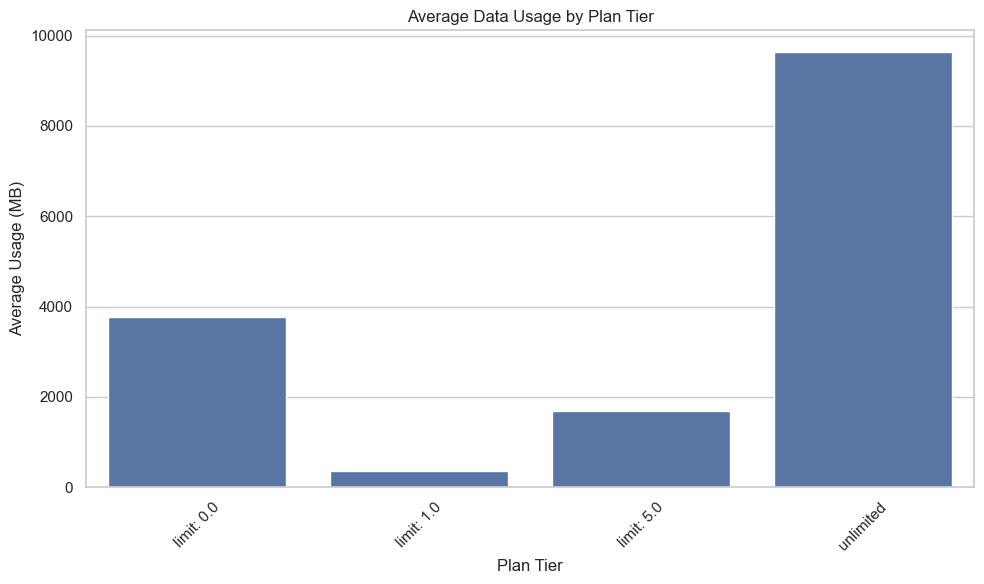

In [25]:
result = %sql SELECT * FROM usage_kpis
;

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(data=result, x='allowance', y='avg_data_used')
plt.title('Average Data Usage by Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('Average Usage (MB)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Observations:
# Unlimited users on average consume 9.6GB per month
# 5GB users on average consume 1.7GB per month
# 1GB users on average consume 366MB per month
# Interestingly there are some subscriptions with zero allowance (in the plan pln_c2e73083cdcd7349ed576eea5f06) that consume
# on average 3.8GB and can go up to 80GB in a month, presumably paying extra for this usage outside their allowance, which could 
# be potentially an opportunity to upsell an unlimited data plan to them (read more after the next chart).

In [36]:
%%sql 
--let's check the usage evolution over month N of subscription
create or replace table usage_kpis_period as
WITH plan_features AS (
SELECT DISTINCT plan_id, is_unlimited_data, data_allowance_mb
FROM plan_events
)
SELECT CASE
          WHEN is_unlimited_data THEN 'unlimited'
          ELSE concat ('limit: ', CAST((data_allowance_mb / 1000) AS text))
        END AS allowance
      , subscription_period_number as month_n
      , AVG(cumulative_data_usage_megabyte) AS avg_data_used
      , MAX(cumulative_data_usage_megabyte) AS max_data_used
FROM usage_data
LEFT JOIN plan_features USING (plan_id)
GROUP BY 1, 2
ORDER BY 1, 2

,Count
0,50


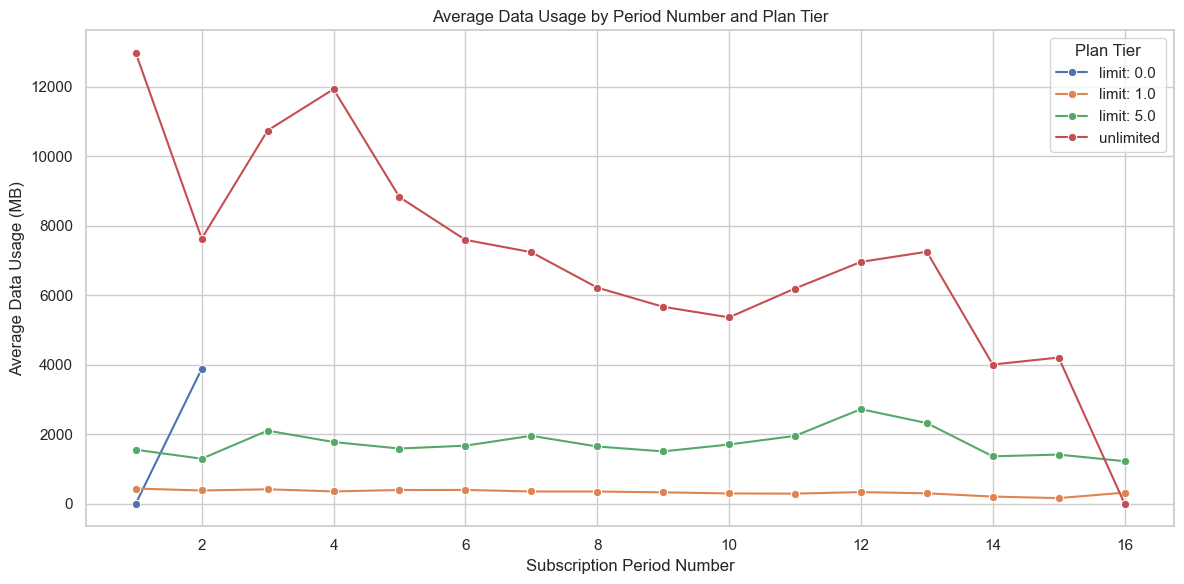

In [70]:
result = %sql SELECT * FROM usage_kpis_period;

plt.figure(figsize=(12, 6))
sns.lineplot(data=result, x='month_n', y='avg_data_used', hue='allowance', marker='o')
plt.title('Average Data Usage by Period Number and Plan Tier')
plt.xlabel('Subscription Period Number')
plt.ylabel('Average Data Usage (MB)')
plt.legend(title='Plan Tier')
plt.tight_layout()
plt.show()

# Observations:
# The users with 1GB and 5G allowances on average follow pretty stable patterns
# On the other hand the users with unlimited plans start very strong and gradually consume less, with an increase around the 12-13th month

In [ ]:
# The subscribers with 0GB allowance only stay for up to 2 months, however they only appear in May-June 2025 and belong to
# the new partner People Mobile. 
# It is not clear from the data if the plan has been cancelled or it continues, so I will not focus on it.

# Note that this plan pln_c2e73083cdcd7349ed576eea5f06 might just be wrong data and should be ignored all together. It has more 
# records with subscription_period_number=2 than records with subscription_period_number=1, which should be impossible. 

In [213]:
%%sql 
--finally let's also check the monthly usage evolution historically, across year x month specifically for the unlimited users
--but by project - hopefully this will allow to understand better what happened
--again I will assume that the start date denotes the calendar month
create or replace table usage_kpis_unlimited_historical as
WITH plan_features AS (
SELECT DISTINCT plan_id, is_unlimited_data, data_allowance_mb
FROM plan_events
where is_unlimited_data
)
SELECT organization_name
      , date_trunc('month', subscription_period_start) as reporting_month
      , AVG(cumulative_data_usage_megabyte) AS avg_data_used
      , MAX(cumulative_data_usage_megabyte) AS max_data_used
      , sum(cumulative_data_usage_megabyte) as total_data_used
      , count(distinct subscription_id) as nr_active_users
FROM usage_data
INNER JOIN plan_features USING (plan_id)
INNER JOIN projects USING (project_id__hashed)
GROUP BY 1, 2
ORDER BY 1, 2

,Count
0,24


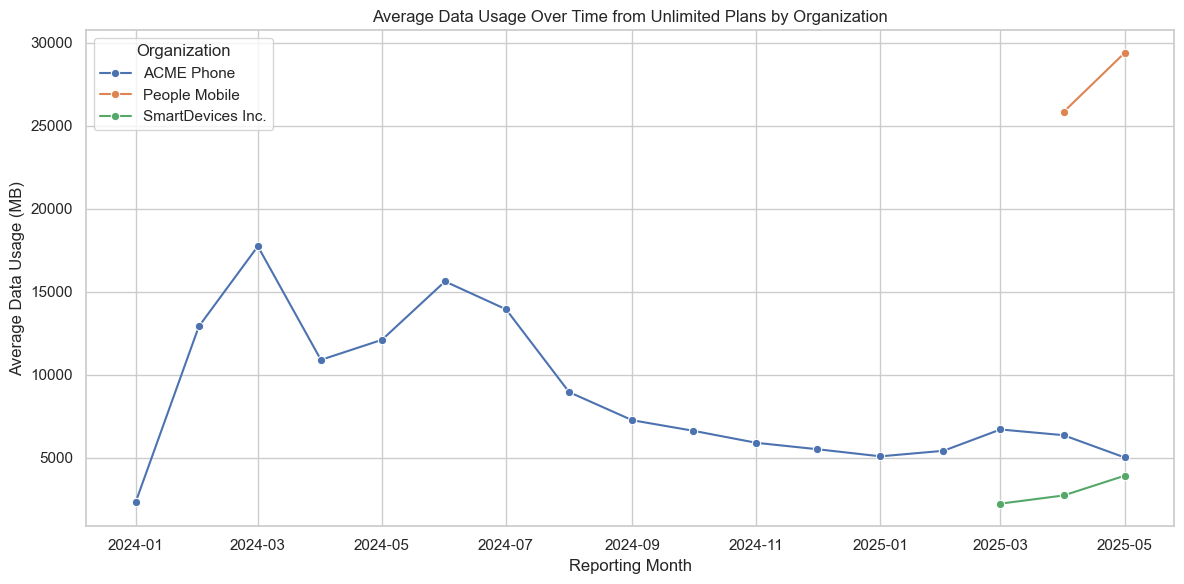

In [85]:
result = %sql SELECT * FROM usage_kpis_unlimited_historical where reporting_month < '2025-06-01';

plt.figure(figsize=(12, 6))
sns.lineplot(data=result, x='reporting_month', y='avg_data_used', hue='organization_name', marker='o')
plt.title('Average Data Usage Over Time from Unlimited Plans by Organization')
plt.xlabel('Reporting Month')
plt.ylabel('Average Data Usage (MB)')
plt.legend(title='Organization')
plt.tight_layout()
plt.show()

# Observations:
# ACME Phone:
# Here we see that the ACME project is the oldest one and we already have more than 12 months of data. It's average usage started 
# above 10GB but gradually decreased. Its users have had a small increase after February 2025 (that we also saw in the chart above).
# In the 2nd chart below we see that the number of active users is dropping very slowly, so the total data usage from this project
# is stable and even increasing a bit.
# People Mobile:
# This has started very strong, with more than 2x the average usage of ACME Phone at >25GB. 
# SmartDevices Inc:
# Lower average usage, probably due to it being used for wearables. Strong increase in May 2025 so we will observe in the next months.

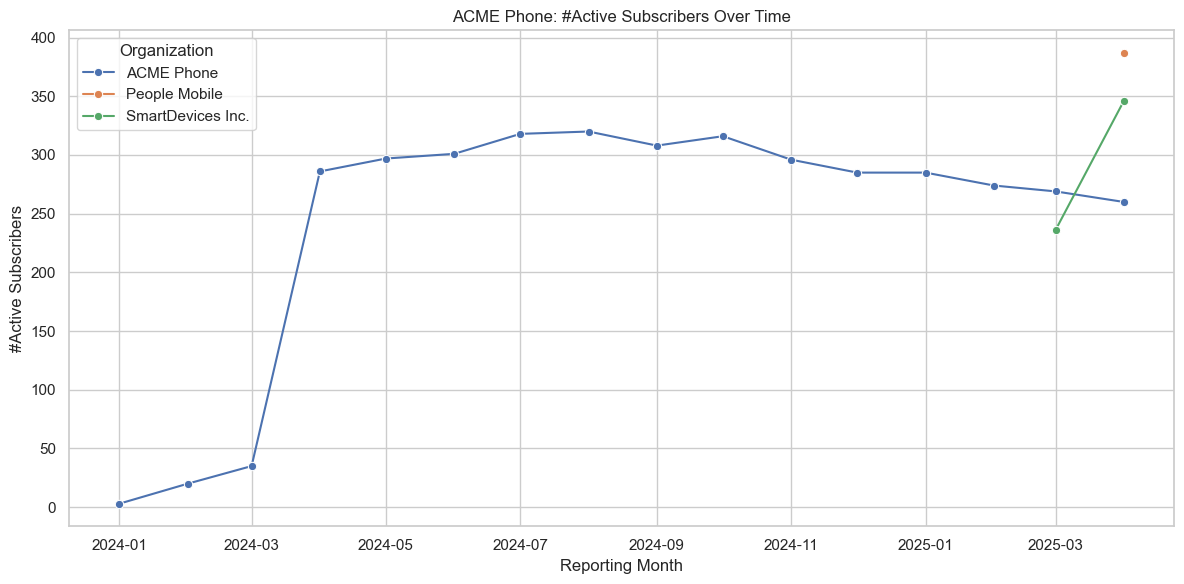

In [87]:
result = %sql SELECT * FROM usage_kpis_unlimited_historical where reporting_month < '2025-05-01';

plt.figure(figsize=(12, 6))
sns.lineplot(data=result, x='reporting_month', y='nr_active_users', hue='organization_name', marker='o')
plt.title('ACME Phone: #Active Subscribers Over Time')
plt.xlabel('Reporting Month')
plt.ylabel('#Active Subscribers')
plt.legend(title='Organization')
plt.tight_layout()
plt.show()


In [ ]:
# Additional analysis that I would do here if there were more time:
# 1. does the price have an impact?
# For example I see unlimited plans at 70$ and unlimited plans at 35$. Does that change usage patterns? Is it maybe linked to
# the organization and therefore already covered by the above analysis?
# 2. do the add-ons have any impact?

In [204]:
number_table = pd.DataFrame({'number': range(1, 61)})

# this will be required to use as "dates since start" in the retention chart
# I will only show the retentio up to 60 days since start due to lack of data for the new projects past that day

In [220]:
%%sql

--the weird plan pln_c2e73083cdcd7349ed576eea5f06 will be ignored

--due to lack of a clear flag that shows if the subscription has churned or not, I discovered that normally when 
--it has churned, in the last period we find that reporting_date = subscription_period_end, so I will use this flag
--for subscription without a reporting_date = subscription_period_end record, I will show June 30 2025 (future date) as end date 

create or replace table subscriber_retention as
with base_data as (
select organization_name, subscription_id, min(subscription_period_start) as subscription_start_date
, coalesce(max(case when reporting_date = subscription_period_end then subscription_period_end end)
        , '2025-06-30') as subscription_end_date
, datediff('day', subscription_start_date, subscription_end_date) as days_active
FROM usage_data as u
inner join plan_events as pl using (plan_id)
INNER JOIN projects as pr on pr.project_id__hashed = u.project_id__hashed
where u.plan_id != 'pln_c2e73083cdcd7349ed576eea5f06'
group by 1, 2
having subscription_start_date < '2025-05-01'
)
, initial_users as (
select organization_name, count(distinct subscription_id) as initial_users
from base_data
group by 1
)
, days as (
select number as day_n
from number_table
)
, expand as (
select *
from base_data
inner join initial_users
  using (organization_name)
inner join days
  on days.day_n < days_active
)
select organization_name, initial_users, day_n
, count(distinct subscription_id) as active_users
, active_users/initial_users as retention_rate
from expand
group by 1, 2, 3
order by 1, 2, 3
;

,Count
0,180


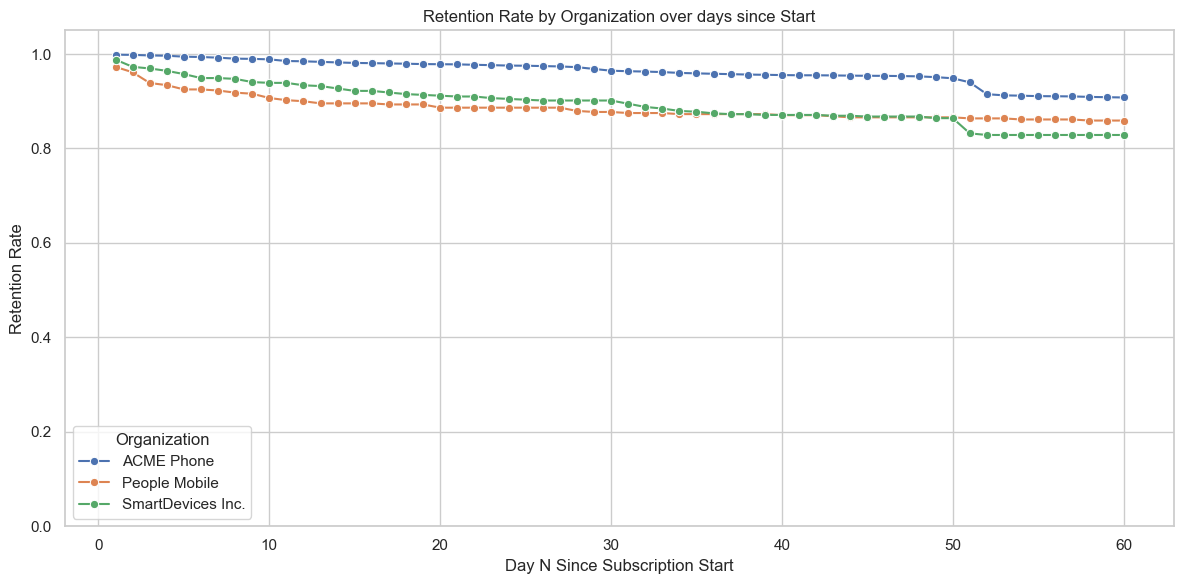

In [222]:
result = %sql SELECT * FROM subscriber_retention;


plt.figure(figsize=(12, 6))
sns.lineplot(data=result, x='day_n', y='retention_rate', hue='organization_name', marker='o')

plt.title('Retention Rate by Organization over days since Start')
plt.xlabel('Day N Since Subscription Start')
plt.ylabel('Retention Rate')
plt.ylim(0, 1.05)  # Optional: keep y-axis between 0 and 1
plt.legend(title='Organization')
plt.grid(True)
plt.tight_layout()
plt.show()

# Observations:
# Although the 2 new projects do not have bad retention rate, it is certainly below ACME Phone which stands >90% after 60 days.
# People Mobile is at ±85% and SmartDevices Inc. is at ±83%



In [ ]:
# Additional notes and analysis

# 1. In the above chart it is possible that the time filters are not 100% correct. 
# If I had more time to do it perfectly, I would start from current date (whenever I am doing the analysis) 
# and only include in the dataset users who have been longer than current date minus maxim data point 
# for example if I want to show 60 days and today it's May 20, I would only include users who started before March 20

# 2. If I had more time I would add additional cohorting to the retention curves, for example:
# by month of acquisition
# by data tier, pricing etc
# 3. Finally it would be interesting to check if some churned subscribers are actually not churned:
# but simply cancelled the existing plan and got a new one with a higher (or lower) allowance.
